In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# 0. 다중 변수 가상 데이터 생성 (데이터 100개)

In [2]:
np.random.seed(42)
X_tv = np.random.uniform(10, 300, 100)      # TV 광고비
X_radio = np.random.uniform(0, 50, 100)     # 라디오 광고비

# 판매량 = 5(기본) + 0.05*TV + 0.15*라디오 + 노이즈(오차)
noise = np.random.normal(0, 2.5, 100)
y_sales = 5 + (0.05 * X_tv) + (0.15 * X_radio) + noise

df = pd.DataFrame({'TV_Ads': X_tv, 'Radio_Ads': X_radio, 'Sales': y_sales})

# 1. 다중선형회귀 모델 학습

In [4]:
# 독립변수(X)가 2개로 늘어났습니다!
X_multi = df[['TV_Ads', 'Radio_Ads']] 
y_target = df['Sales']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# [시각화] 3D 산점도 및 회귀 평면(Regression Plane) 그리기

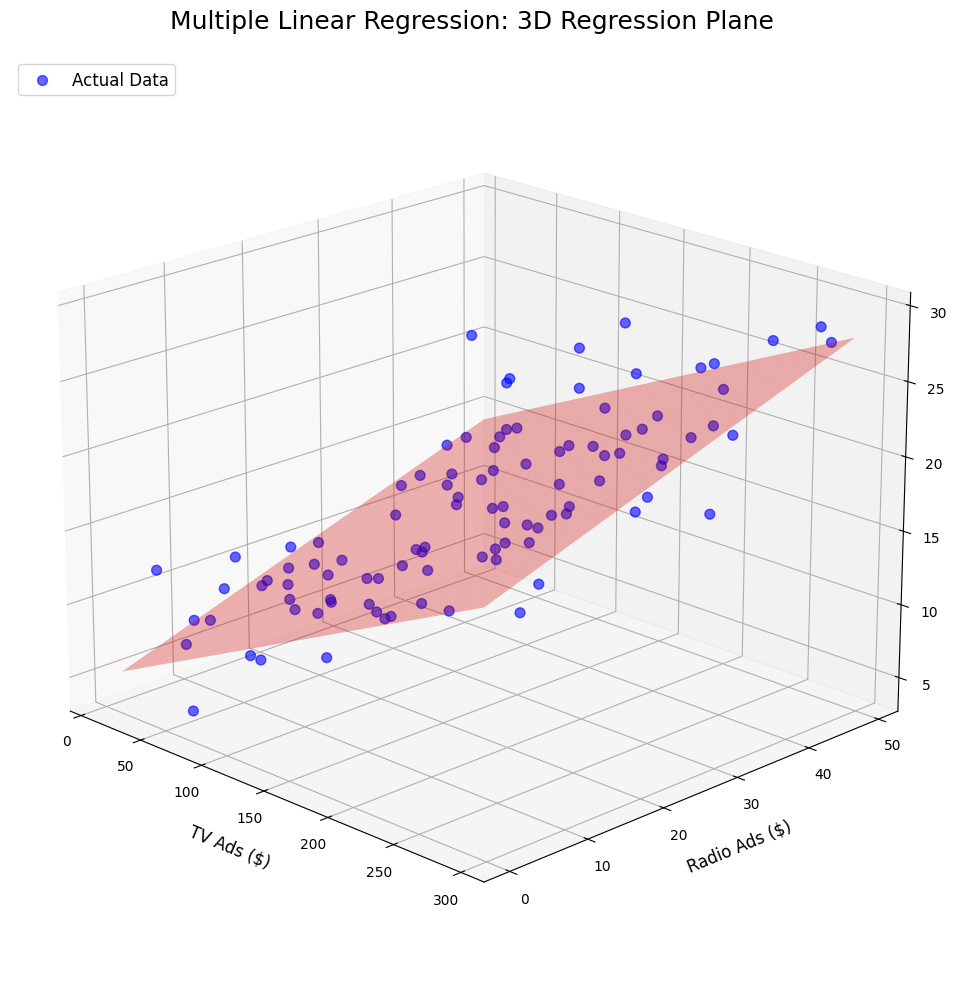

In [6]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d') # 3D 축 생성

# 1. 실제 데이터 산점도 (파란색 구슬)
ax.scatter(df['TV_Ads'], df['Radio_Ads'], df['Sales'], 
           color='blue', marker='o', s=50, alpha=0.6, label='Actual Data')

# 2. 회귀 평면(Plane)을 그리기 위한 3D 격자점(Grid) 생성
x_surf, y_surf = np.meshgrid(np.linspace(df['TV_Ads'].min(), df['TV_Ads'].max(), 20),
                             np.linspace(df['Radio_Ads'].min(), df['Radio_Ads'].max(), 20))
# 만들어진 격자점(TV, Radio)을 모델에 넣어서 해당 위치의 예측 판매량(Z축) 계산
X_grid = pd.DataFrame({'TV_Ads': x_surf.ravel(), 'Radio_Ads': y_surf.ravel()})
z_surf = model_multi.predict(X_grid).reshape(x_surf.shape)

# 3. 예측 평면 그리기 (붉은색 반투명 평면)
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3)

# 축 라벨 및 타이틀 설정
ax.set_title('Multiple Linear Regression: 3D Regression Plane', fontsize=18, pad=20)
ax.set_xlabel('TV Ads ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Radio Ads ($)', fontsize=12, labelpad=10)
ax.set_zlabel('Sales (Units)', fontsize=12, labelpad=10)
ax.legend(loc='upper left', fontsize=12)

# 카메라 각도 조절 (평면이 잘 보이도록)
ax.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()

# 2. 모델 학습 결과(회귀 계수) 텍스트 출력

In [7]:
print("=== 다중선형회귀 학습 결과 ===")
print(f"절편 (기본 판매량, 베타0): {model_multi.intercept_:.4f}")
print(f"TV 광고 계수 (베타1): {model_multi.coef_[0]:.4f}")
print(f"라디오 광고 계수 (베타2): {model_multi.coef_[1]:.4f}")

=== 다중선형회귀 학습 결과 ===
절편 (기본 판매량, 베타0): 4.8060
TV 광고 계수 (베타1): 0.0471
라디오 광고 계수 (베타2): 0.1860


# 3. 모델 성능 평가 (결정계수 및 잔차 표준 오차 계산)

In [8]:
from sklearn.metrics import r2_score

# 모델이 예측한 판매량(Y) 값들을 구합니다.
y_pred_multi = model_multi.predict(X_multi)

# 1) 결정계수 (R-squared) 계산
r2 = r2_score(y_target, y_pred_multi)

# 2) 잔차 표준 오차 (RSE: Residual Standard Error) 계산
n = len(y_target)             # 데이터의 총 개수 (100개)
p = X_multi.shape[1]          # 독립변수(원인)의 개수 (TV, Radio = 2개)
rss = np.sum((y_target - y_pred_multi) ** 2)  # 잔차(실제값-예측값) 제곱의 합
rse = np.sqrt(rss / (n - p - 1))              # RSE 공식 적용

print("\n=== 모델 성능 평가 (채점 결과) ===")
print(f"결정계수 (R^2 Score): {r2:.4f}")
print(f"잔차 표준 오차 (RSE): {rse:.4f}")


=== 모델 성능 평가 (채점 결과) ===
결정계수 (R^2 Score): 0.7950
잔차 표준 오차 (RSE): 2.4685
